# Discrete State Space Model for Phasor Networks

Instead of solving a continuous ODE (`dz/dt = kz + I(t)`), we discretize the
Resonate-and-Fire neuron into a linear recurrence:

$$z[n+1] = A \cdot z[n] + B \cdot I[n]$$

where $A = \exp(k \cdot \Delta t)$, $B = (A-1)/k$, $k = \lambda + i\omega$.

Unrolling gives a **causal convolution**: $z[n] = \sum_j K[n-j] \cdot I[j]$, $K[n] = A^n \cdot B$,
computable in parallel via matrix multiply (small L) or FFT (large L).

This is the same insight behind **S4/S4D/Mamba**: diagonal complex state spaces
are equivalent to complex convolution kernels.

| Spiking system | SSM equivalent | Meaning |
|---|---|---|
| `spk_args.leakage` | `λ = -exp(log_neg_lambda)` | Decay rate (spiral inward speed) |
| `2π / spk_args.t_period` | `ω` (omega) | Angular frequency (rotation speed) |
| `solve(ODEProblem(...))` | `causal_conv(K, H)` | Temporal integration |
| `PhasorDense` weight | `ps.weight` | Channel mixing matrix |

The **SSMReadout** layer computes codebook similarity at every timestep before
averaging, avoiding phase-cancellation from averaging rotating phasors directly.

In [ ]:
using PhasorNetworks
using Lux, Random, Optimisers, Zygote, Statistics
using MLDatasets, MLUtils, OneHotArrays
using CUDA, LuxCUDA
using Plots

## 1. Discrete Phasor Kernel and Causal Convolution

The R&F neuron ODE `dz/dt = (λ + iω)z + I(t)` has exact discrete solution:

$$z[n+1] = \underbrace{\exp(k \Delta t)}_{A} \cdot z[n] + \underbrace{\frac{A-1}{k}}_{B} \cdot I[n]$$

Unrolling: $z[n] = \sum_{j=0}^{n} A^{n-j} B \cdot I[j]$ — a causal convolution with kernel $K[n] = A^n B$.

`phasor_kernel(λ, ω, Δt, L)` precomputes the full kernel, and `causal_conv(K, H)` applies it
via a lower-triangular Toeplitz matrix multiply (GPU-friendly via `batched_mul`).
Both functions are provided by the PhasorNetworks package.

## 2. PhasorSSM, SSMSelfAttention, and SSMReadout

**PhasorSSM** — the SSM equivalent of `PhasorDense`. Trainable per-channel `(λ, ω)` + real weight matrix for channel mixing.

**SSMSelfAttention** — phasor self-attention for complex-valued sequences:

1. Projects input to complex queries (Q), keys (K), and values (V) via dense sub-networks
2. Computes QK scores via `similarity_outer` (pairwise phase similarity in [-1, 1])
3. Applies exponential score scaling via `score_scale`
4. Weights values by scaled scores, renormalizes to the unit circle

Since Q and K share the same temporal extent L, the output preserves the sequence
dimension — making this a drop-in layer in a `Chain`.

**SSMReadout** — computes codebook similarity at every timestep before averaging.
This avoids the phase-cancellation problem: averaging rotating complex vectors
directly causes destructive interference, but averaging scalar similarity scores
preserves class-discriminative information.

## 3. PSK Encoding

FashionMNIST images (28×28) are encoded as complex time series via `psk_encode`:
- **Columns → channels** (C=28), **Rows → time steps** (L=28)
- Pixel value $v \in [0,1] \to$ phase $\theta = 2v-1 \in [-1,1] \to \exp(i\pi\theta)$

## 4. Visualize Initial Causal Kernels

Before training, let's visualize what the impulse-response kernel looks like for
oscillators at different frequencies and decay rates.

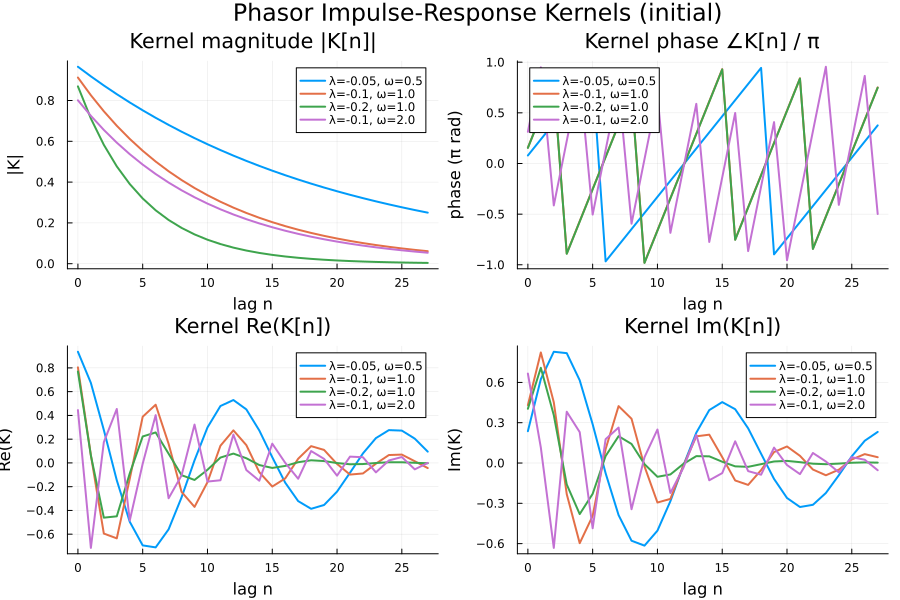

In [13]:
# Show kernels for a few representative oscillators
L_viz = 28
λ_viz = Float32[-0.05, -0.1, -0.2, -0.1]
ω_viz = Float32[0.5, 1.0, 1.0, 2.0]
K_viz = phasor_kernel(λ_viz, ω_viz, 1f0, L_viz)  # 4 × 28

labels = ["λ=-0.05, ω=0.5" "λ=-0.1, ω=1.0" "λ=-0.2, ω=1.0" "λ=-0.1, ω=2.0"]
ts = 0:L_viz-1

p1 = plot(ts, abs.(K_viz)', title="Kernel magnitude |K[n]|",
          xlabel="lag n", ylabel="|K|", label=labels, lw=2,
          legend=:topright)

p2 = plot(ts, angle.(K_viz)' ./ π, title="Kernel phase ∠K[n] / π",
          xlabel="lag n", ylabel="phase (π rad)", label=labels, lw=2,
          legend=:topleft)

p3 = plot(ts, real.(K_viz)', title="Kernel Re(K[n])",
          xlabel="lag n", ylabel="Re(K)", label=labels, lw=2)

p4 = plot(ts, imag.(K_viz)', title="Kernel Im(K[n])",
          xlabel="lag n", ylabel="Im(K)", label=labels, lw=2)

plot(p1, p2, p3, p4; layout=(2, 2), size=(900, 600),
     plot_title="Phasor Impulse-Response Kernels (initial)")

## 5. Model, Loss, and Data

The model is a `Chain` of `PhasorSSM` → `SSMSelfAttention` → `PhasorSSM` → `SSMReadout`.
The self-attention layer enables dynamic content-based routing between the two
SSM temporal-integration stages. The readout layer holds a fixed random codebook
in its state and computes similarity-based logits.

In [ ]:
function create_model(; D_hidden=128, n_classes=10, C_in=28)
    model = Chain(
        PhasorSSM(C_in => D_hidden, normalize_to_unit_circle),
        SSMSelfAttention(D_hidden => D_hidden, normalize_to_unit_circle),
        PhasorSSM(D_hidden => D_hidden, identity),
        SSMReadout(D_hidden => n_classes),
    )
    return model
end

function ssm_loss(x, y, model, ps, st)
    x_enc = psk_encode(x)
    sims, _ = model(x_enc, ps, st)
    return mean(similarity_loss(sims, y))
end

function evaluate(model, ps, st, loader, device)
    correct = 0; total = 0
    for (x, y) in loader
        x_dev = x |> device
        y_dev = y |> device
        x_enc = psk_encode(x_dev)
        sims, _ = model(x_enc, ps, st)
        correct += sum(argmax(sims; dims=1) .== argmax(y_dev; dims=1))
        total += size(x, 3)
    end
    return correct / total
end

In [23]:
seed = 42
D_hidden = 128
n_epochs = 25
batchsize = 128
lr = 3e-4

0.0003

In [24]:
rng = Xoshiro(seed)

println("Loading FashionMNIST...")
train_data = FashionMNIST(split=:train)
test_data  = FashionMNIST(split=:test)

x_train = Float32.(train_data.features)
y_train = Float32.(onehotbatch(train_data.targets, 0:9))
x_test  = Float32.(test_data.features)
y_test  = Float32.(onehotbatch(test_data.targets, 0:9))

train_loader = DataLoader((x_train, y_train); batchsize, shuffle=true)
test_loader  = DataLoader((x_test,  y_test);  batchsize)

println("Building model (D_hidden=$D_hidden)...")
model = create_model(; D_hidden, n_classes=10, C_in=28)
ps, st = Lux.setup(rng, model)

_count(nt::NamedTuple) = isempty(nt) ? 0 : sum(_count(v) for v in values(nt))
_count(x::AbstractArray) = length(x)
_count(_) = 0
println("  Trainable parameters: $(_count(ps))")

use_cuda = CUDA.functional()
device = use_cuda ? gpu_device() : cpu_device()
ps = ps |> device
st = st |> device
println("  Device: $(use_cuda ? "CUDA GPU" : "CPU")")

Loading FashionMNIST...
Building model (D_hidden=128)...
  Trainable parameters: 20480
  Device: CUDA GPU


## 6. Similarity Through Time

To visualize how the SSM network discriminates between classes, we compute
codebook similarity at **every timestep** (not just the readout window).

For each sample, we forward through the two SSM layers, extract phase angles
at each timestep, and compute cosine similarity against every codebook prototype.
The **red line** shows similarity to the true class; gray lines show all others.

In [ ]:
"""
Compute per-class similarity at every timestep.
Forwards through all layers except the readout (last layer), then computes
codebook similarity at each time step.
Returns (n_classes × L × B) Float32 array.
"""
function similarity_through_time(model, ps, st, x_enc)
    # Forward through all layers except readout (last layer)
    n = length(model.layers)
    z = x_enc
    for i in 1:(n-1)
        sym = Symbol("layer_$i")
        z, _ = model.layers[i](z, getproperty(ps, sym), getproperty(st, sym))
    end

    C, L, B = size(z)
    z_norm = normalize_to_unit_circle(z)
    phases = complex_to_angle(z_norm)          # C × L × B (Phase)

    readout_st = getproperty(st, Symbol("layer_$n"))
    codes = readout_st.codes                   # C × n_classes (Phase)
    n_cls = size(codes, 2)

    # Cosine similarity at each timestep
    p = reshape(phases, C, 1, L, B)            # C × 1 × L × B
    c = reshape(codes, C, n_cls, 1, 1)         # C × n_classes × 1 × 1
    cos_diff = cos.(Float32(π) .* (p .- c))    # C × n_classes × L × B
    sims = mean(cos_diff; dims=1)              # 1 × n_classes × L × B
    return dropdims(sims; dims=1)              # n_classes × L × B
end

class_labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

function plot_similarity_grid(sims, y_samples, title_str)
    plots = []
    for (i, cls) in enumerate(y_samples)
        p = plot(title=class_labels[cls+1], xlabel="time step", ylabel="similarity",
                 legend=false)
        for c in 1:10
            c == cls + 1 && continue
            plot!(p, 1:size(sims, 2), sims[c, :, i], color=:gray, alpha=0.25, lw=0.8)
        end
        plot!(p, 1:size(sims, 2), sims[cls+1, :, i], color=:red, lw=2.5)
        push!(plots, p)
    end
    plot(plots...; layout=(2, 3), size=(1100, 550), plot_title=title_str)
end

In [ ]:
# Pick one sample from each of 6 classes for visualization
sample_indices = [findfirst(==(c), train_data.targets) for c in 0:5]
x_samples = x_train[:, :, sample_indices] |> device
y_samples = train_data.targets[sample_indices]

# Compute similarity at every timestep with initial (untrained) parameters
x_enc_samples = psk_encode(x_samples)
sims_pre = similarity_through_time(model, ps, st, x_enc_samples) |> cpu_device()

plot_similarity_grid(sims_pre, y_samples,
    "Similarity Through Time (Before Training)")

## 7. Training

Uses the package's `train()` function with `similarity_loss` and the SSMReadout's
built-in codebook for classification.

In [25]:
args = Args(epochs=1, batchsize=batchsize, lr=lr, use_cuda=use_cuda)
all_losses = Float64[]
epoch_accs = Float64[]

for epoch in 1:n_epochs
    losses, ps, st = train(model, ps, st, train_loader, ssm_loss, args)
    append!(all_losses, losses)
    acc = evaluate(model, ps, st, test_loader, device)
    push!(epoch_accs, acc)
    println("Epoch $epoch/$n_epochs  avg_loss=$(round(mean(losses); digits=4))  test_acc=$(round(acc; digits=4))")
end

┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1325


Epoch 1/25  avg_loss=0.6572  test_acc=0.5455


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1325


Epoch 2/25  avg_loss=0.4728  test_acc=0.6374


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1325


...

Epoch 23/25  avg_loss=0.2083  test_acc=0.778


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1325


Epoch 24/25  avg_loss=0.2062  test_acc=0.7769


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1325


Epoch 25/25  avg_loss=0.2044  test_acc=0.7776


## 8. Training Results

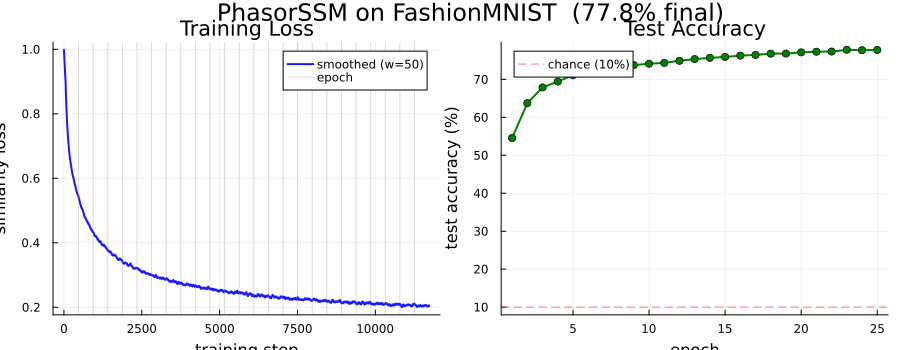

In [26]:
steps_per_epoch = length(all_losses) ÷ n_epochs

# Smooth loss with a running average
window = min(50, steps_per_epoch)
smoothed = [mean(all_losses[max(1,i-window+1):i]) for i in 1:length(all_losses)]

p_loss = plot(smoothed, xlabel="training step", ylabel="similarity loss",
              title="Training Loss", label="smoothed (w=$window)",
              lw=2, color=:blue, alpha=0.9)
# Add epoch boundaries
for e in 1:n_epochs-1
    vline!([e * steps_per_epoch], color=:gray, alpha=0.3, label=(e==1 ? "epoch" : nothing))
end

p_acc = plot(1:n_epochs, epoch_accs .* 100,
             xlabel="epoch", ylabel="test accuracy (%)",
             title="Test Accuracy", label=nothing,
             lw=2, marker=:circle, color=:green)
hline!([100/10], color=:red, ls=:dash, alpha=0.5, label="chance (10%)")

plot(p_loss, p_acc; layout=(1, 2), size=(900, 350),
     plot_title="PhasorSSM on FashionMNIST  ($(round(epoch_accs[end]*100; digits=1))% final)")

## 9. Similarity Through Time (After Training)

After training, the SSM layers have learned to produce phase patterns that align
with the codebook prototypes for the correct class. The true class (red) should
now stand out from the other classes (gray) at each timestep.

In [ ]:
# Compute similarity at every timestep with trained parameters
sims_post = similarity_through_time(model, ps, st, psk_encode(x_samples)) |> cpu_device()

plot_similarity_grid(sims_post, y_samples,
    "Similarity Through Time (After Training)")

## 10. Learned Kernels

After training, the oscillator parameters `(λ, ω)` have been adjusted by gradient descent.
Let's see how the learned kernels compare to the initial uniform spread.

In [ ]:
# Extract learned PhasorSSM parameters (layers 1 and 3) from CPU
ps_cpu = ps |> cpu_device()
ps_l1 = ps_cpu.layer_1   # first PhasorSSM
ps_l3 = ps_cpu.layer_3   # second PhasorSSM (after attention)

λ_l1 = -exp.(ps_l1.log_neg_lambda)
ω_l1 = ps_l1.omega
λ_l3 = -exp.(ps_l3.log_neg_lambda)
ω_l3 = ps_l3.omega

K_l1 = phasor_kernel(λ_l1, ω_l1, 1f0, 28)
K_l3 = phasor_kernel(λ_l3, ω_l3, 1f0, 28)

# Select a few channels to visualize
ch_show = [1, 32, 64, 96, 128]
ts = 0:27

p_mag1 = plot(title="Layer 1 (SSM): |K[n]|", xlabel="lag n", ylabel="|K|")
p_mag2 = plot(title="Layer 3 (SSM): |K[n]|", xlabel="lag n", ylabel="|K|")
for c in ch_show
    plot!(p_mag1, ts, abs.(K_l1[c, :]), label="ch $c", lw=1.5)
    plot!(p_mag2, ts, abs.(K_l3[c, :]), label="ch $c", lw=1.5)
end

# Distribution of learned λ and ω
p_params = scatter(ω_l1, λ_l1, xlabel="ω (rad/step)", ylabel="λ (decay)",
                   title="Learned (λ, ω)",
                   label="layer 1 (SSM)", marker=:circle, ms=3, alpha=0.6, color=:blue)
scatter!(p_params, ω_l3, λ_l3,
         label="layer 3 (SSM)", marker=:diamond, ms=3, alpha=0.6, color=:red)

# Heatmap of full kernel magnitude for layer 1
p_heat = heatmap(0:27, 1:D_hidden, abs.(K_l1),
                 xlabel="lag n", ylabel="channel",
                 title="Layer 1: |K| heatmap", color=:viridis)

plot(p_mag1, p_mag2, p_params, p_heat;
     layout=(2, 2), size=(900, 700),
     plot_title="Learned Phasor Kernels")

## Summary

The discrete SSM approach replaces the continuous ODE solver with a precomputed
convolution kernel, giving **identical dynamics** but with parallel computation.

**Self-attention**: The `SSMSelfAttention` layer between the two SSM stages enables
dynamic content-based routing — each time step attends to all others via phasor
phase similarity, allowing the network to selectively combine temporal features
before the second SSM stage integrates them.

**Similarity-based readout**: The `SSMReadout` layer computes codebook similarity
at every timestep before averaging. This avoids phase-cancellation — the mean of
rotating phasors tends toward zero, but similarity scores are scalar and
rotation-invariant, so they can be meaningfully averaged over time.

**Key observations:**
- Before training, similarity curves are flat and noisy — no class is distinguishable.
- After training, the correct class consistently achieves highest similarity,
  with separation emerging as temporal context accumulates across the sequence.
- The learned decay rates `λ` and frequencies `ω` diverge from initialization,
  adapting temporal receptive fields to the data.
- Faster-decaying channels act as short-term feature detectors;
  slower-decaying channels integrate over longer time spans.